  <h1><center>Modèle de  Volterra</center></h1>

Le premier modèle de type “prédateur-proie” a été proposé par le mathématicien italien Vito Volterra au début des années 1920. Le but de ce modèle était d’expliquer le phénomène suivant, observé à l’époque par le bureau de la pêche italienne de Trieste : pendant la Première Guerre Mondiale, période où la pêche était très réduite, la proportion de requins et autres prédateurs impropres à la consommation qu’on attrapait était nettement supérieure à ce qu’elle était avant-guerre, et à ce qu’elle redevint ensuite.\\

Le modèle de Volterra est le suivant. Soit x(t) le nombre de proies (i.e.
les poissons comestibles) et y(t) le nombre de prédateurs (requins et autres).
On va écrire un système différentiel en faisant les hypothèses suivantes :


  *  la population des proies n’est limitée que par les prédateurs et en leur
absence croît exponentiellement ;
  * la population des prédateurs est totalement dépendante des proies et en
leur absence décroît exponentiellement.

En termes mathématiques, l’énoncé nous dit qu’en l’absence d’interactions entre proies et prédateurs, on a
$$x'(t) = ax(t) \quad et \quad  y'(t)=-cy(t),$$
où $a$ et $c$ sont des constantes positives. D’autre part, chaque rencontre entre proie et prédateur est bonne pour le prédateur et mauvaise pour la proie. On peut supposer le nombre de rencontres proportionnel au produit $x(t)y(t)$.
Ainsi, l’évolution avec interaction peut être décrite par le système

$$\left\{\begin{array}{ccc}x'(t) &=& ax(t)- bx(t) y(t), \\
\\
y'(t) &=&  -cy(t)+f x(t) y(t),
\end{array}\right.$$

Si l’on connaît les constantes $a$; $b$; $c$; $f$ et les population à un instant $t_0$,
ce système décrit l’évolution future de chaque population : est-ce qu’elles
vont augmenter, ou diminuer? À quelle vitesse? Pourquoi la pêche influencet-elle le nombre de prédateurs?

# 1- *Simulation numérique*
## 1.1- Méthode d'Euler

In [1]:
%pylab inline  

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


La fonction d'euler explicite prend en entrée $f$, le temps initial $t_0$, le temps final $t_f$, la condition initiale $x_0$  et $N$ le nombre de points de discritisation.

In [2]:
def euler_explicite(f,ti,tf,x0,N):
    h=(tf-ti)/N
    t,x=linspace(ti,tf,N+1),[]
    x.append(x0)
    for n in range(N):
        x.append(x[n]+h*f(x[n],t[n]))
    return t,x

Notre modèle de lokta volterra est donné par la fonction suivante

In [3]:
def lokta_volterra(x,t) :
    a=1
    b=2
    c=2
    d=1
    return array([a*x[0]-b*x[0]*x[1], -c*x[1]+d*x[0]*x[1]])

Les lignes de code suivantes servent à tracer les graphes des variables $x$ et $y$ sur l'intervalle $[0,20]$ en partant respectivement de 3 et de 2.

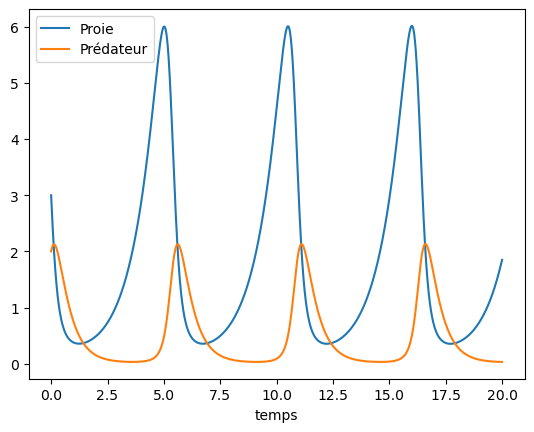

In [4]:
x0=array([3,2]) # la condition initiale 
t,x=euler_explicite(lokta_volterra,0,20,x0,10**5) # appel à la fonction euler_explicite pour 
# l'appliquer à f=lokta_volterra, t_0=0, t_f=20, x0=(3,2) et N=10 000.
[p1,p2]=plot(t,x)# pour tracer la solution en fonction de t
legend([p1,p2],["Proie","Prédateur"])
xlabel('temps')
show() #  pour la clarté de l'image (n'est pas obligatoire) 

Traçage du diagramme de phase

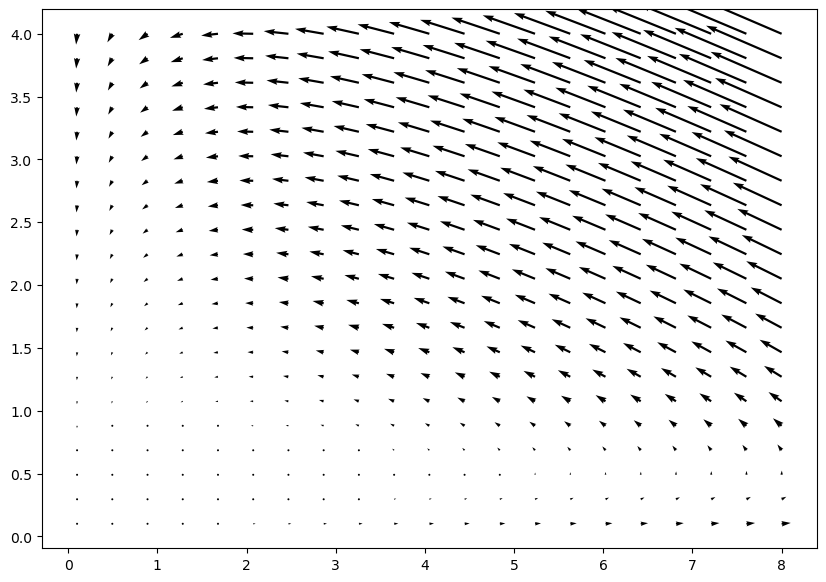

In [5]:
Y1,Y2 = meshgrid(linspace(0.1,8,21),linspace(0.1,4,21))
V1,V2 =lokta_volterra([Y1,Y2],1) 
figure(figsize=(10,7))
quiver(Y1, Y2, V1, V2, units='width')

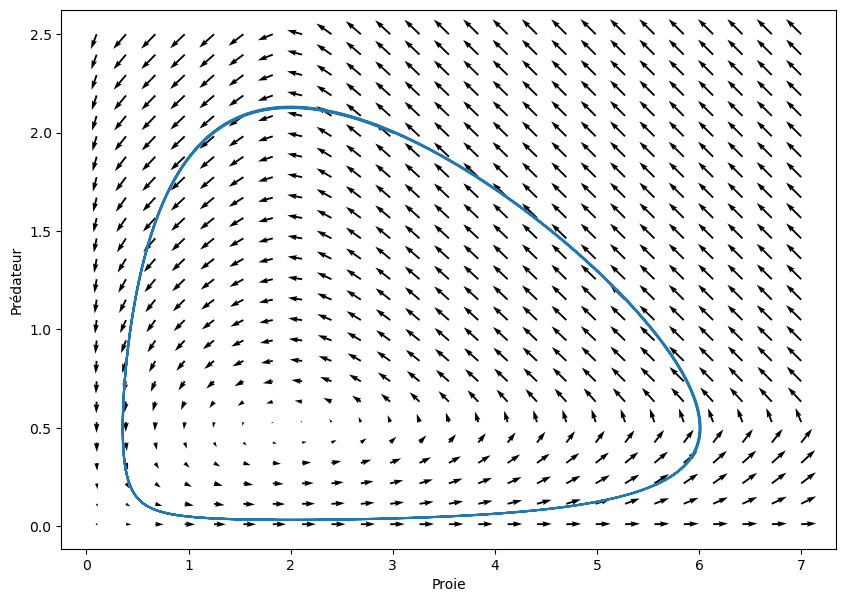

In [6]:
Y1,Y2 = meshgrid(linspace(0.1,7,25),linspace(0.01,2.5,25))
V1,V2 =lokta_volterra([Y1,Y2],1) 
r1 = sqrt(1+V1**2)
r2 = sqrt(1+V2**2)
figure(figsize=(10,7))
quiver(Y1, Y2, V1/r1, V2/r2, units='width')

xx=[y[0] for y in x]    # pour extraire tou les abscisses des x 
yy=[y[1] for y in x]    # pour extraire tou les ordonnées des x
plot(xx,yy)             # pour tracer la variable y en fonction y 
xlabel('Proie')
ylabel('Prédateur')
show()

Le code suivant donne une solution de référence, c'est à dire une solution très précise. Pour ce la on va utiliser une fonction prédéfinie dans python. On importe cette fonction depuis scipy.integrate.


In [7]:
from scipy.integrate import odeint

In [8]:
t=linspace(0,10,10**6)
xr=odeint(lokta_volterra,x0,t)

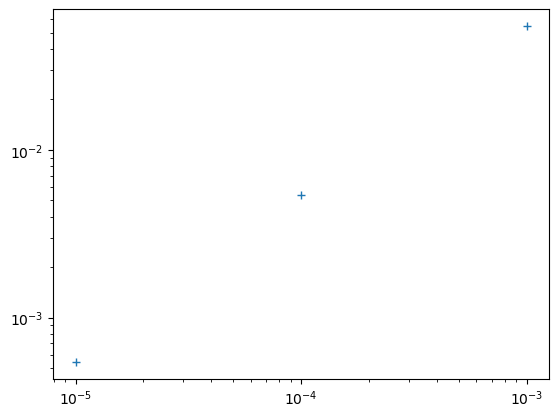

In [9]:
xref,err,h=xr[-1],[],[]
for i in range(3,6) :
    N=10**(i+1)
    h.append(10/N)
    t,x=euler_explicite(lokta_volterra,0,10,x0,N)
    err.append(norm(xref-x[-1]))
loglog(h,err,'+')

In [10]:
err

[0.054890258056286945, 0.005414461031769652, 0.0005437949657783419]

L'ordre de convergence effectif vaut 1.0020300448917818


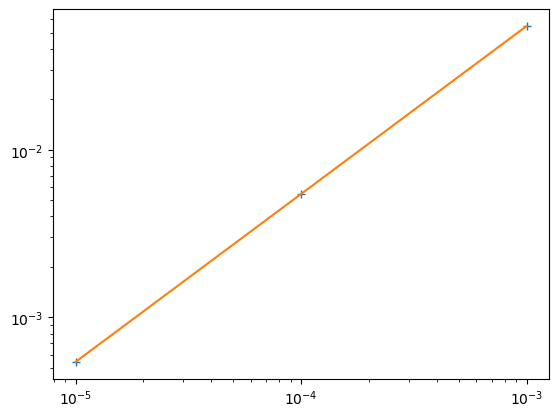

In [11]:
slope=polyfit(log(h),log(err),1)
loglog(h,err,'+',h,exp(slope[1])*(h**(slope[0])))
print("L'ordre de convergence effectif vaut",slope[0])

## 1.2 Méthode de runge Kutta

In [12]:
def rk4(f,ti,tf,x0,N):
    h=(tf-ti)/N
    t,x=linspace(ti,tf,N+1),[]
    x.append(x0)
    for n in range(N):
        k1=f(x[n],t[n])
        k2=f(x[n]+0.5*h*k1,t[n]+0.5*h)
        k3=f(x[n]+0.5*h*k2,t[n]+0.5*h)
        k4=f(x[n]+h*k3,t[n]+h)
        x.append(x[n]+h*(k1+2*(k2+k3)+k4)/6)
    return t,x

In [13]:
t=linspace(0,10,2**9)
xr=odeint(lokta_volterra,x0,t)

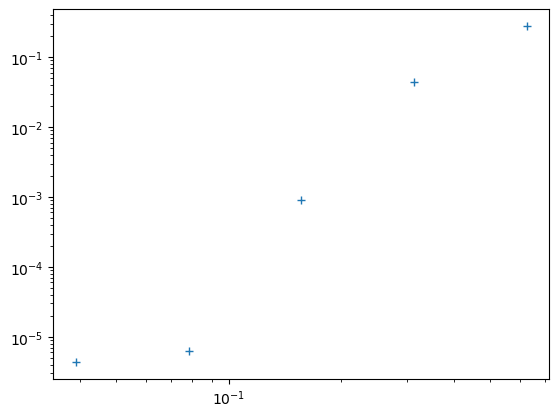

In [14]:
xref,err1,h1=xr[-1],[],[]
for i in range(3,8) :
    N=2**(i+1)
    h1.append(10/N)
    t,x=rk4(lokta_volterra,0,10,x0,N)
    err1.append(norm(xref-x[-1]))
loglog(h1,err1,'+')

L'ordre de convergence effectif vaut 4.471868324607104


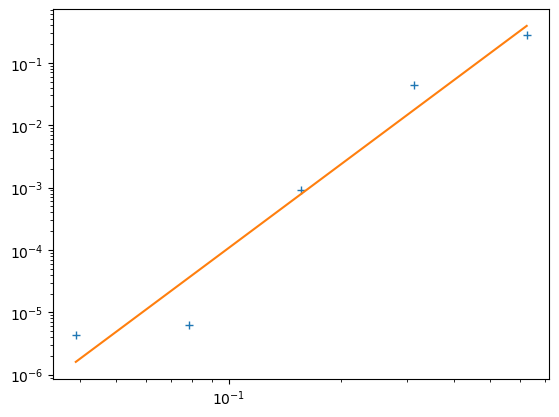

In [15]:
slope=polyfit(log(h1),log(err1),1)
loglog(h1,err1,'+',h1,exp(slope[1])*(h1**(slope[0])))
print("L'ordre de convergence effectif vaut",slope[0])

## 1.3 Comparaison des deux méthodes

# 2. Evolution du modèle Lotka Volterra
## 2.1 L'ajout de la pêche
L’effet de la pêche est de prélever une certaine proportion de chacune des
espèces. Dans le système différentiel, ceci revient à retrancher $ \epsilon x$ à $x'$ et $\eta y$
à y' $(\eta> 0)$, c’est-à-dire que l’équation devient :
$$\left\{\begin{array}{ccc}x'(t) &=& (a-\epsilon)  x(t)- bx(t) y(t), \\
\\
y'(t) &=&  -(c+\eta) y(t)+d x(t) y(t),
\end{array}\right.$$
Les coordonnées du nouveau point d’équilibre (c’est-à-dire les nouvelles populations moyennes) sont

$$\overline{x}=\dfrac{c+\eta}{d}>\dfrac{c}{d} \quad  \text{et} \quad\overline{x}=\dfrac{a-\epsilon}{b}<\dfrac{a}{b}. $$
Ce point d’équilibre est donc situé plus bas et plus à droite que l’ancien,
d’où ce résultat étonnant : la pêche tend à augmenter le nombre moyen de
poissons comestibles!

In [16]:
def lokta_volterra_peche(x,t) :
    a=1
    b=2
    c=2
    d=1
    eta=0.7
    epsilon=0.6
    return array([(a-epsilon)*x[0]-b*x[0]*x[1], -(c+eta)*x[1]+d*x[0]*x[1]])

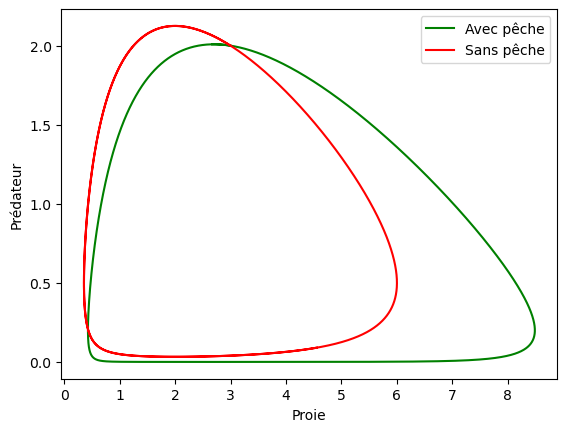

In [17]:
t,x=rk4(lokta_volterra_peche,0,10,x0,10**5)
xxp=[y[0] for y in x]    # pour extraire tou les abscisses des x 
yyp=[y[1] for y in x]  # pour extraire tou les ordonnées des x
plot(xxp,yyp,'g',label="Avec pêche")  
legend()
t,x=rk4(lokta_volterra,0,10,x0,10**5)
xx=[y[0] for y in x]    # pour extraire tou les abscisses des x 
yy=[y[1] for y in x]
plot(xx,yy,'r',label="Sans pêche") # pour tracer la variable y en fonction y 
xlabel('Proie')
ylabel('Prédateur')
legend()
show()

In [18]:
def lokta_volterra_modifiee(x,t) :
    a=1
    b=2
    c=2
    d=1
    eps=.1
    return array([a*x[0]-b*x[0]*x[1]-eps*x[0]**2, -c*x[1]+d*x[0]*x[1]-eps*x[1]**2])


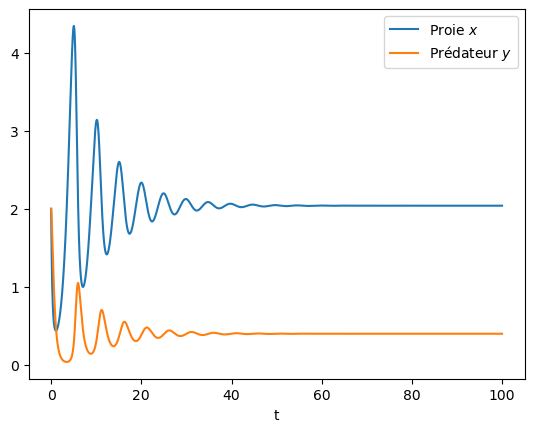

In [19]:

x0=array([2,2])
t,x=rk4(lokta_volterra_modifiee,0,100,x0,10**5)
plot(t,x,label=["Proie $x$ ","Prédateur $y$"])
xlabel('t')
plt.legend()
show()

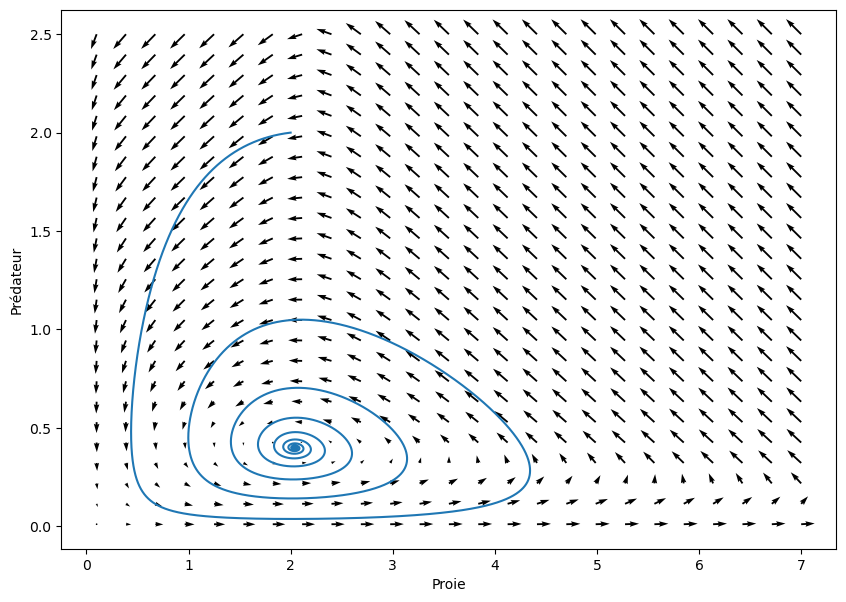

In [20]:
Y1,Y2 = meshgrid(linspace(0.1,7,25),linspace(0.01,2.5,25))
V1,V2 =lokta_volterra_modifiee([Y1,Y2],1) 
r1 = sqrt(1+V1**2)
r2 = sqrt(1+V2**2)
figure(figsize=(10,7))
quiver(Y1, Y2, V1/r1, V2/r2, units='width')

xx=[y[0] for y in x]    # pour extraire tou les abscisses des x 
yy=[y[1] for y in x]    # pour extraire tou les ordonnées des x
plot(xx,yy)             # pour tracer la variable y en fonction y 
xlabel('Proie')
ylabel('Prédateur')
show()